# Transformer para la detección de puntos de cambio en trayectorias de difusión anómala

Este cuaderno implementa una arquitectura Transformer para estimar la posición del punto de cambio en trayectorias sintéticas de difusión anómala. El protocolo se mantiene igual que en los modelos ConvLSTM, LSTM y ConvTransformer: se carga la base sintética ya generada, se entrena el modelo, se evalúa el error global y se analizan los resultados por transición ordenada entre modelos de difusión.

La entrada del modelo se construye a partir de cuatro canales derivados de cada trayectoria: la señal normalizada `x(t)`, el incremento temporal `dx(t)`, su valor absoluto `|dx(t)|` y el término cuadrático `dx(t)^2`. Esta representación permite que el Transformer reciba información sobre la evolución local de la trayectoria antes de estimar la posición del punto de cambio.

## 1. Importación de librerías

Se cargan únicamente las librerías necesarias para lectura de datos, entrenamiento del modelo, evaluación y visualización de resultados.

In [1]:
import random
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import layers, models, optimizers, losses, metrics, callbacks

## 2. Configuración experimental

Esta versión está preparada para ejecutar el entrenamiento completo solicitado: `FAST_RUN = False`, 200 000 trayectorias de entrenamiento, 20 000 de validación y 200 000 de prueba. El conjunto de prueba mantiene 10 000 trayectorias por cada transición ordenada entre modelos de difusión.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

LENGTH = 100
MIN_SEGMENT_LENGTH = 20

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]

FAST_RUN = False
FAST_TRAIN_SIZE = 200000
FAST_VAL_SIZE = 20000
FAST_TEST_SIZE = 200000

EPOCHS = 80
BATCH_SIZE = 256
PREDICT_BATCH_SIZE = 2048

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_changepoint_andi"
OUTPUT_DIR = PROJECT_ROOT / "model_outputs" / "transformer_4features_results_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Carga de la base sintética

Cada archivo HDF5 contiene las trayectorias `X`, la posición real del punto de cambio `cp`, los modelos de difusión antes y después del cambio (`model1`, `model2`), los exponentes anómalos y el nivel de ruido. Los identificadores numéricos de los modelos se transforman a sus nombres: `ATTM`, `CTRW`, `FBM`, `LW` y `SBM`.

La función `load_split` carga y normaliza la trayectoria original `x(t)`. La construcción de las cuatro entradas del modelo se hace después para mantener clara la diferencia entre la trayectoria cargada y la entrada final del Transformer.

In [3]:
MODEL_MAP = {
    0: "ATTM",
    1: "CTRW",
    2: "FBM",
    3: "LW",
    4: "SBM"
}


def decode_model_values(values):
    decoded = []
    for value in np.asarray(values).reshape(-1):
        if isinstance(value, np.generic):
            value = value.item()
        if isinstance(value, bytes):
            value = value.decode("utf-8")
        try:
            decoded.append(MODEL_MAP[int(value)])
        except Exception:
            decoded.append(str(value).replace("b'", "").replace("'", "").strip().upper())
    return decoded


def load_split(split_name):
    h5_path = DATA_DIR / f"{split_name}_L100_dim1.h5"

    with h5py.File(h5_path, "r") as file:
        x = file["X"][:].astype("float32")
        positions = file["cp"][:].astype("float32")
        model1 = decode_model_values(file["model1"][:])
        model2 = decode_model_values(file["model2"][:])
        alpha1 = file["alpha1"][:]
        alpha2 = file["alpha2"][:]
        noise_sigma = file["noise_sigma"][:]

    if x.ndim == 2:
        x = x[:, :, None]

    x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-8)
    y = (positions / LENGTH).astype("float32")

    metadata = pd.DataFrame({
        "cp": positions,
        "model1": model1,
        "model2": model2,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "noise_sigma": noise_sigma
    })

    metadata["transition"] = metadata["model1"] + " → " + metadata["model2"]

    return x, positions, y, metadata


def balanced_fast_subset(x, positions, y, metadata, total_size, seed=42):
    rng = np.random.default_rng(seed)
    groups = metadata.groupby(["model1", "model2"]).indices
    per_group = max(1, total_size // len(groups))
    selected_indices = []

    for indices in groups.values():
        indices = np.array(list(indices))
        size = min(per_group, len(indices))
        selected_indices.extend(rng.choice(indices, size=size, replace=False))

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return (
        x[selected_indices],
        positions[selected_indices],
        y[selected_indices],
        metadata.iloc[selected_indices].reset_index(drop=True)
    )

## 4. Preparación para el entrenamiento

Antes de entrenar la red, cada trayectoria normalizada se transforma en una representación de cuatro canales. El primer canal conserva la señal `x(t)`, mientras que los otros tres describen variaciones locales de la trayectoria:

1. `x(t)`: trayectoria normalizada.
2. `dx(t)`: incremento temporal entre puntos consecutivos.
3. `|dx(t)|`: magnitud local del desplazamiento.
4. `dx(t)^2`: intensidad cuadrática del cambio local.

La salida del modelo sigue siendo la posición del punto de cambio normalizada entre 0 y 1. Después de la predicción, ese valor se reescala a puntos temporales para calcular los errores MAE y RMSE.

Con esta preparación, la forma de entrada pasa de `(N, 100, 1)` a `(N, 100, 4)`, manteniendo intacta la arquitectura del Transformer.

In [4]:
x_train_raw, train_positions, y_train, train_metadata = load_split("train")
x_val_raw, val_positions, y_val, val_metadata = load_split("val")
x_test_raw, test_positions, y_test, test_metadata = load_split("test")

if FAST_RUN:
    x_train_raw, train_positions, y_train, train_metadata = balanced_fast_subset(
        x_train_raw, train_positions, y_train, train_metadata, FAST_TRAIN_SIZE, SEED
    )
    x_val_raw, val_positions, y_val, val_metadata = balanced_fast_subset(
        x_val_raw, val_positions, y_val, val_metadata, FAST_VAL_SIZE, SEED
    )
    x_test_raw, test_positions, y_test, test_metadata = balanced_fast_subset(
        x_test_raw, test_positions, y_test, test_metadata, FAST_TEST_SIZE, SEED
    )


def make_features(x):
    # Construye cuatro canales informativos: x(t), dx(t), |dx(t)| y dx(t)^2.
    position = x[:, :, 0]
    dx = np.diff(position, axis=1, prepend=position[:, :1])
    abs_dx = np.abs(dx)
    dx2 = dx ** 2

    features = np.stack([position, dx, abs_dx, dx2], axis=-1)

    # Normalización por trayectoria y por canal.
    features = (
        features - features.mean(axis=1, keepdims=True)
    ) / (
        features.std(axis=1, keepdims=True) + 1e-8
    )

    return features.astype("float32")


# Entradas finales del Transformer: (N, 100, 4)
x_train = make_features(x_train_raw)
x_val = make_features(x_val_raw)
x_test = make_features(x_test_raw)

split_size_frame = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "trajectories": [len(x_train), len(x_val), len(x_test)],
    "raw_shape": [x_train_raw.shape, x_val_raw.shape, x_test_raw.shape],
    "model_input_shape": [x_train.shape, x_val.shape, x_test.shape]
})

display(split_size_frame)
display(test_metadata["transition"].value_counts().sort_index())

,split,trajectories,raw_shape,model_input_shape
0,train,200000,"(200000, 100, 1)","(200000, 100, 4)"
1,validation,20000,"(20000, 100, 1)","(20000, 100, 4)"
2,test,200000,"(200000, 100, 1)","(200000, 100, 4)"


transition
ATTM → CTRW    10000
ATTM → FBM     10000
ATTM → LW      10000
ATTM → SBM     10000
CTRW → ATTM    10000
CTRW → FBM     10000
CTRW → LW      10000
CTRW → SBM     10000
FBM → ATTM     10000
FBM → CTRW     10000
FBM → LW       10000
FBM → SBM      10000
LW → ATTM      10000
LW → CTRW      10000
LW → FBM       10000
LW → SBM       10000
SBM → ATTM     10000
SBM → CTRW     10000
SBM → FBM      10000
SBM → LW       10000
Name: count, dtype: int64

## 5. Visualización inicial de trayectorias

Se muestran ejemplos de trayectorias junto con su punto de cambio real. La visualización utiliza el primer canal de la entrada, correspondiente a `x(t)`, para comprobar de forma directa la estructura temporal de las señales antes del entrenamiento.

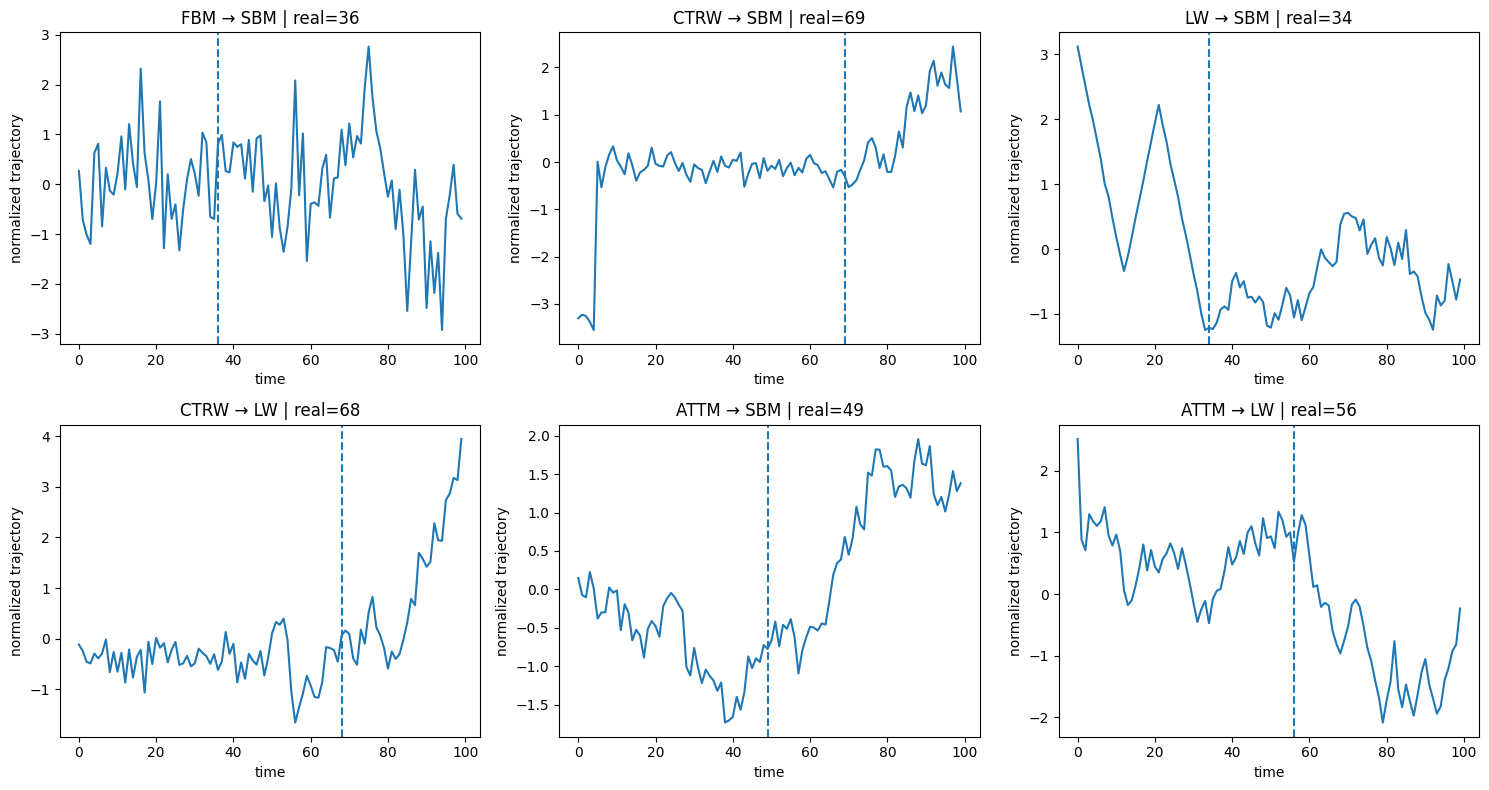

In [5]:
def plot_examples(x, positions, metadata, n_examples=6):
    n_examples = min(n_examples, len(x))
    selected = np.random.choice(len(x), size=n_examples, replace=False)
    columns = 3
    rows = int(np.ceil(n_examples / columns))

    plt.figure(figsize=(15, 4 * rows))

    for panel, index in enumerate(selected, start=1):
        plt.subplot(rows, columns, panel)
        plt.plot(x[index, :, 0])
        plt.axvline(int(positions[index]), linestyle="--")
        plt.title(f"{metadata.loc[index, 'transition']} | real={int(positions[index])}")
        plt.xlabel("time")
        plt.ylabel("normalized trajectory")

    plt.tight_layout()
    plt.show()


plot_examples(x_train, train_positions, train_metadata)

## 6. Construcción del modelo Transformer

El modelo proyecta la entrada de cuatro canales en un espacio latente mediante una capa densa inicial. A continuación, se añade una codificación posicional aprendible para que la red conserve información sobre el orden temporal de los puntos.

Los bloques de auto-atención multi-cabeza permiten comparar distintas posiciones dentro de la misma trayectoria. La salida final es una regresión directa de la posición normalizada del punto de cambio.

Esta versión debe interpretarse como un Transformer con entrada enriquecida, no como un ConvTransformer, ya que no se añaden capas convolucionales.

In [6]:
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, model_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.model_dim = model_dim
        self.position_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=model_dim
        )

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        encoded_positions = self.position_embedding(positions)
        return inputs + encoded_positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "model_dim": self.model_dim
        })
        return config


def transformer_encoder_block(inputs, model_dim, num_heads, feedforward_dim, dropout_rate):
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=model_dim // num_heads,
        dropout=dropout_rate
    )(inputs, inputs)

    x = layers.Add()([inputs, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    feedforward_output = layers.Dense(feedforward_dim, activation="relu")(x)
    feedforward_output = layers.Dropout(dropout_rate)(feedforward_output)
    feedforward_output = layers.Dense(model_dim)(feedforward_output)

    x = layers.Add()([x, feedforward_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x


def build_transformer_changepoint_model(
    input_shape,
    model_dim=64,
    num_heads=4,
    feedforward_dim=128,
    num_blocks=3,
    dropout_rate=0.20
):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(model_dim)(inputs)
    x = PositionalEmbedding(input_shape[0], model_dim)(x)

    for _ in range(num_blocks):
        x = transformer_encoder_block(
            x,
            model_dim=model_dim,
            num_heads=num_heads,
            feedforward_dim=feedforward_dim,
            dropout_rate=dropout_rate
        )

    average_pooling = layers.GlobalAveragePooling1D()(x)
    max_pooling = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([average_pooling, max_pooling])

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="transformer_changepoint_regressor"
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=losses.Huber(delta=0.05),
        metrics=[metrics.MeanAbsoluteError(name="mae")]
    )

    return model


model = build_transformer_changepoint_model(input_shape=x_train.shape[1:])
model.summary()

Model: "transformer_changepoint_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 4)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100, 64)           │             320 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ positional_embedding          │ (None, 100, 64)           │           6,400 │ dense[0][0]                │
│ (PositionalEmbedding)         │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 100, 64)           │          16,640 │ positional_embedding[0][0… │
│ (MultiHeadAttention)          │                           │                 │ positional_embedding[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 64)           │               0 │ positional_embedding[0][0… │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 100, 64)           │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100, 128)          │           8,320 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 100, 128)          │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 100, 64)           │           8,256 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 100, 64)           │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 100, 64)           │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 100, 64)           │          16,640 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 100, 64)           │               0 │ layer_normalization_1[0][… │
│                               │                           │                 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 115,457 (451.00 KB)

 Trainable params: 115,457 (451.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento

El entrenamiento utiliza el mismo esquema general que el Transformer base: optimización con Adam, función de pérdida Huber, MAE como métrica de seguimiento, parada temprana, reducción automática de la tasa de aprendizaje y guardado del mejor modelo.

La modificación principal está en los datos entregados a la red. En lugar de recibir una única señal por instante temporal, el modelo recibe cuatro canales que resumen tanto la posición normalizada como los cambios locales de la trayectoria.

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

model_checkpoint = callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_transformer_changepoint.keras",
    monitor="val_mae",
    save_best_only=True
)

csv_logger = callbacks.CSVLogger(
    OUTPUT_DIR / "transformer_training_log.csv",
    append=True
)

backup = callbacks.BackupAndRestore(
    backup_dir=str(OUTPUT_DIR / "transformer_training_backup")
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, model_checkpoint, csv_logger, backup],
    verbose=1
)

Epoch 1/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 744s 906ms/step - loss: 0.0064 - mae: 0.1510 - val_loss: 0.0059 - val_mae: 0.1409 - learning_rate: 0.0010
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 532s 680ms/step - loss: 0.0056 - mae: 0.1351 - val_loss: 0.0052 - val_mae: 0.1262 - learning_rate: 0.0010
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 590s 755ms/step - loss: 0.0049 - mae: 0.1212 - val_loss: 0.0046 - val_mae: 0.1130 - learning_rate: 0.0010
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 595s 761ms/step - loss: 0.0045 - mae: 0.1126 - val_loss: 0.0042 - val_mae: 0.1060 - learning_rate: 0.0010
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 695s 889ms/step - loss: 0.0043 - mae: 0.1081 - val_loss: 0.0041 - val_mae: 0.1030 - learning_rate: 0.0010
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 729s 932ms/step - loss: 0.0042 - mae: 0.1049 - val_loss: 0.0040 - val_mae: 0.1010 - learning_rate: 0.0010
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 736s 941ms/step - loss: 0.0041 - mae: 0.1025 - val_loss: 0.0039 - val_mae: 0.0983 - 

## 8. Evolución del entrenamiento

Se representan la pérdida y el MAE durante el entrenamiento y la validación. Para facilitar la interpretación, el MAE se expresa en puntos temporales, lo que permite relacionar directamente el error con la escala real de la trayectoria.

,loss,mae,val_loss,val_mae,learning_rate
65,0.002952,0.078266,0.003074,0.079546,0.00001
66,0.002958,0.078373,0.003075,0.079580,0.00001
67,0.002956,0.078367,0.003074,0.079559,0.00001
68,0.002950,0.078228,0.003073,0.079526,0.00001
69,0.002947,0.078161,0.003074,0.079543,0.00001


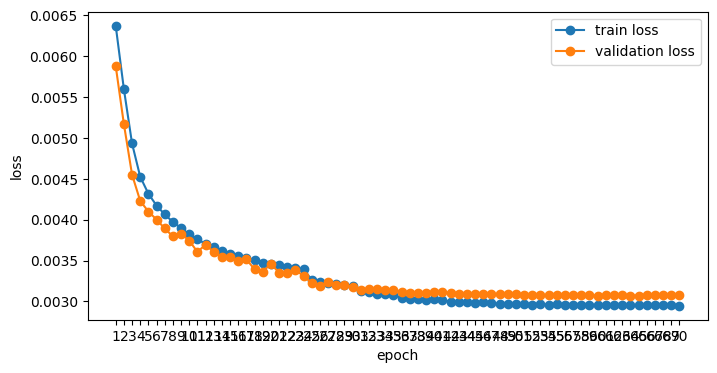

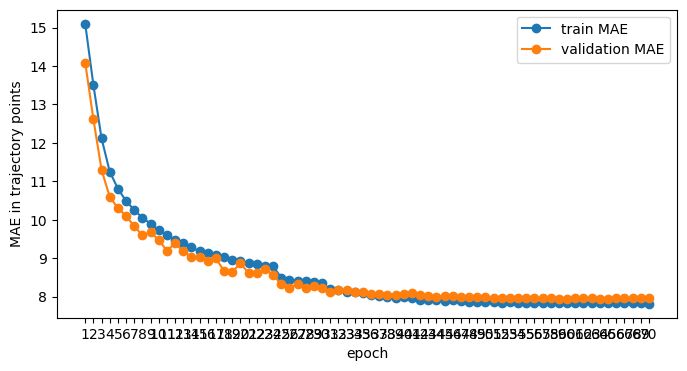

In [8]:
history_frame = pd.DataFrame(history.history)

display(history_frame.tail())

epochs_range = range(1, len(history_frame) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["loss"], marker="o", label="train loss")
plt.plot(epochs_range, history_frame["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(epochs_range)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_frame["mae"] * LENGTH, marker="o", label="train MAE")
plt.plot(epochs_range, history_frame["val_mae"] * LENGTH, marker="o", label="validation MAE")
plt.xlabel("epoch")
plt.ylabel("MAE in trajectory points")
plt.xticks(epochs_range)
plt.legend()
plt.show()

## 9. Predicción y métricas globales

El Transformer devuelve una posición normalizada para cada trayectoria del conjunto de prueba. Esa predicción se transforma de nuevo a la escala temporal original y se limita al intervalo permitido por la longitud mínima de cada segmento.

A partir de las predicciones finales se calculan las métricas globales MAE y RMSE, medidas en puntos temporales.

In [9]:
def predict_positions(model, x):
    predicted_normalized = model.predict(
        x,
        batch_size=PREDICT_BATCH_SIZE,
        verbose=0
    ).reshape(-1)

    predicted_positions = np.rint(predicted_normalized * LENGTH).astype(np.int32)
    predicted_positions = np.clip(
        predicted_positions,
        MIN_SEGMENT_LENGTH,
        LENGTH - MIN_SEGMENT_LENGTH
    )

    return predicted_positions, predicted_normalized


predicted_test_positions, predicted_test_normalized = predict_positions(model, x_test)

test_mae = mean_absolute_error(test_positions, predicted_test_positions)
test_rmse = np.sqrt(mean_squared_error(test_positions, predicted_test_positions))

global_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE"],
    "value_in_points": [test_mae, test_rmse]
})

global_metrics

,metric,value_in_points
0,MAE,7.866905
1,RMSE,12.373875


## 10. Resultados por transición ordenada

Las métricas se calculan también para cada transición `model1 → model2`. Este análisis permite observar si el rendimiento del modelo depende del tipo de dinámica antes y después del punto de cambio.

La comparación por parejas ayuda a identificar transiciones más simples y casos donde la estimación sigue siendo más difícil.

In [10]:
result_frame = test_metadata.copy().reset_index(drop=True)
result_frame["true_changepoint"] = test_positions
result_frame["predicted_changepoint"] = predicted_test_positions
result_frame["error"] = result_frame["predicted_changepoint"] - result_frame["true_changepoint"]
result_frame["absolute_error"] = result_frame["error"].abs()
result_frame["predicted_normalized"] = predicted_test_normalized

pair_metrics = (
    result_frame
    .groupby(["model1", "model2"])
    .agg(
        samples=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda values: float(np.sqrt(np.mean(np.square(values))))),
        median_absolute_error=("absolute_error", "median"),
        mean_bias=("error", "mean")
    )
    .reset_index()
    .sort_values("mae")
)

pair_metrics["transition"] = pair_metrics["model1"] + " → " + pair_metrics["model2"]
pair_metrics = pair_metrics[
    ["transition", "model1", "model2", "samples", "mae", "rmse", "median_absolute_error", "mean_bias"]
]

pair_metrics

,transition,model1,model2,samples,mae,rmse,median_absolute_error,mean_bias
6,CTRW → LW,CTRW,LW,10000,3.5179,6.796668,1.0,0.0305
13,LW → CTRW,LW,CTRW,10000,3.7218,7.033690,1.0,0.1064
2,ATTM → LW,ATTM,LW,10000,5.7941,10.157859,2.0,-0.2583
12,LW → ATTM,LW,ATTM,10000,6.0103,10.125606,2.0,1.1839
5,CTRW → FBM,CTRW,FBM,10000,6.3017,10.775523,3.0,0.9939
15,LW → SBM,LW,SBM,10000,6.3772,10.697888,2.0,0.6720
9,FBM → CTRW,FBM,CTRW,10000,6.4551,10.537158,3.0,-0.8775
7,CTRW → SBM,CTRW,SBM,10000,6.5516,10.809126,3.0,1.5252
10,FBM → LW,FBM,LW,10000,6.8281,11.421283,3.0,-0.6445
17,SBM → CTRW,SBM,CTRW,10000,6.8292,10.971344,3.0,-0.9062


## 11. Matriz de error por transición

La matriz resume el MAE obtenido para cada combinación ordenada de modelos de difusión. Las filas representan el modelo antes del cambio y las columnas el modelo posterior.

Esta vista facilita detectar patrones globales de error y comparar rápidamente el comportamiento del Transformer entre diferentes tipos de transición.

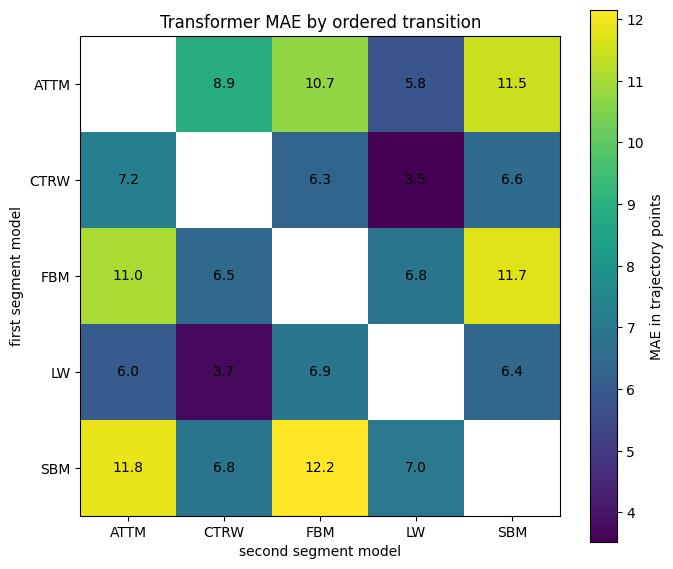

In [11]:
heatmap = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)

for _, row in pair_metrics.iterrows():
    if row["model1"] in MODELS and row["model2"] in MODELS:
        heatmap.loc[row["model1"], row["model2"]] = row["mae"]

plt.figure(figsize=(7, 6))
plt.imshow(heatmap.values.astype(float))
plt.xticks(range(len(MODELS)), MODELS)
plt.yticks(range(len(MODELS)), MODELS)
plt.xlabel("second segment model")
plt.ylabel("first segment model")
plt.title("Transformer MAE by ordered transition")
plt.colorbar(label="MAE in trajectory points")

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            plt.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 12. Panel de trayectorias por transición

Se selecciona una trayectoria representativa para cada transición ordenada. En cada gráfico se compara el punto de cambio real con la posición estimada por el modelo.

Este panel ofrece una lectura cualitativa de los resultados y complementa las métricas numéricas calculadas previamente.

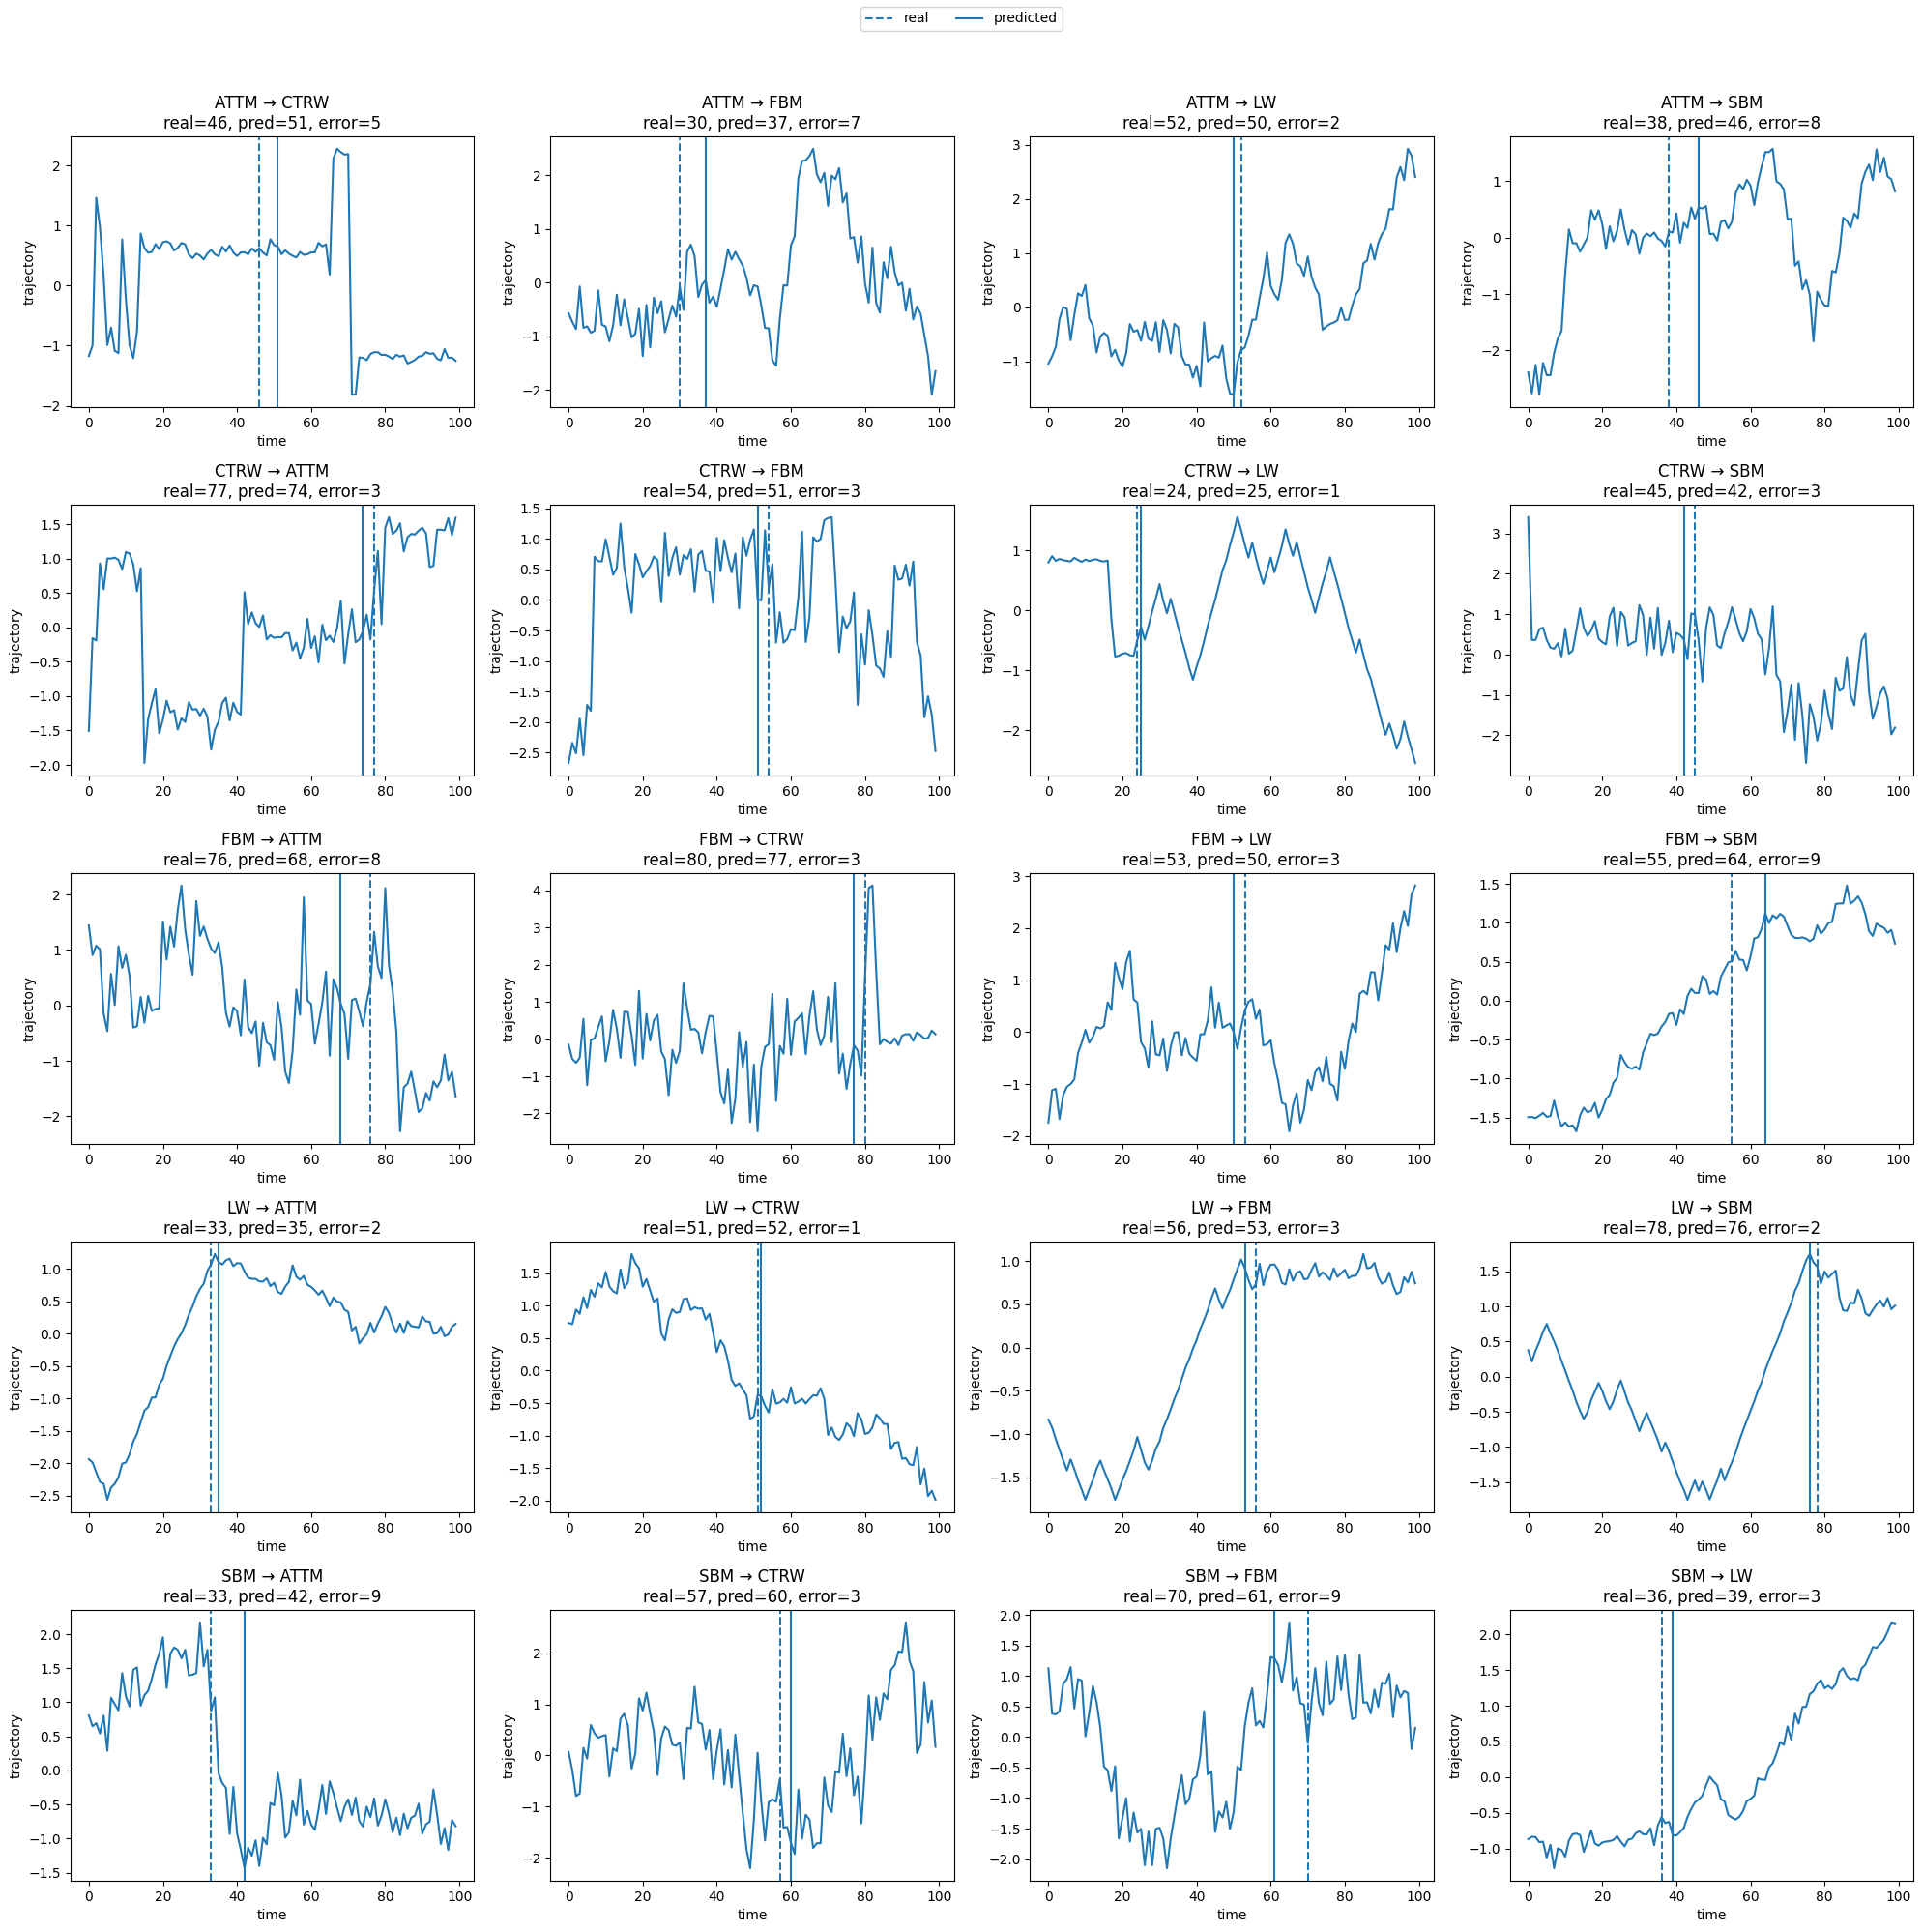

In [12]:
def representative_index_for_pair(frame, model1, model2):
    candidates = frame[(frame["model1"] == model1) & (frame["model2"] == model2)]

    if candidates.empty:
        return None

    target_error = candidates["absolute_error"].median()
    distances = (candidates["absolute_error"] - target_error).abs()

    return int(distances.idxmin())


def plot_transition_panel(x, results, max_pairs=20):
    selected_pairs = TRANSITIONS[:max_pairs]
    columns = 4
    rows = int(np.ceil(len(selected_pairs) / columns))

    plt.figure(figsize=(20, 4 * rows))

    for panel, (model1, model2) in enumerate(selected_pairs, start=1):
        index = representative_index_for_pair(results, model1, model2)
        plt.subplot(rows, columns, panel)

        if index is None:
            plt.title(f"{model1} → {model2}\nno data")
            plt.axis("off")
            continue

        values = x[index, :, 0]
        real_position = int(results.loc[index, "true_changepoint"])
        predicted_position = int(results.loc[index, "predicted_changepoint"])
        absolute_error = float(results.loc[index, "absolute_error"])

        plt.plot(values)
        plt.axvline(real_position, linestyle="--", label="real")
        plt.axvline(predicted_position, linestyle="-", label="predicted")

        plt.title(
            f"{model1} → {model2}\n"
            f"real={real_position}, pred={predicted_position}, error={absolute_error:.0f}"
        )

        plt.xlabel("time")
        plt.ylabel("trajectory")

    handles, labels = plt.gca().get_legend_handles_labels()

    if handles:
        plt.figlegend(handles, labels, loc="upper center", ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_transition_panel(x_test, result_frame)

## 13. Guardado de resultados

Las métricas globales, las métricas por transición, las predicciones individuales y el modelo entrenado se guardan en el directorio de salida.

Estos archivos permiten reutilizar los resultados para comparaciones posteriores con otros modelos del repositorio.

In [13]:
global_metrics.to_csv(OUTPUT_DIR / "transformer_global_metrics.csv", index=False)
pair_metrics.to_csv(OUTPUT_DIR / "transformer_pair_metrics.csv", index=False)
result_frame.to_csv(OUTPUT_DIR / "transformer_test_predictions.csv", index=False)
model.save(OUTPUT_DIR / "transformer_changepoint_final.keras")

print(f"Results saved in: {OUTPUT_DIR.resolve()}")

Results saved in: C:\Users\chair\OneDrive\Bureau\transformer_4features_results_final


## 14. Conclusión

El modelo Transformer fue aplicado a trayectorias sintéticas de longitud **L = 100**, formadas por dos fragmentos con dinámicas de difusión diferentes. Su objetivo fue estimar la posición temporal donde se produce el cambio entre ambos segmentos.

La entrada del modelo se construyó con cuatro canales: la trayectoria normalizada `x(t)`, el incremento temporal `dx(t)`, su valor absoluto `|dx(t)|` y el término cuadrático `dx(t)^2`. Esta representación aporta información local sobre los desplazamientos de la partícula y permite al Transformer analizar mejor los cambios en la dinámica temporal.

La ejecución final se hizo con `FAST_RUN = False`, usando **200.000** trayectorias para entrenamiento, **20.000** para validación y **200.000** para prueba. El conjunto de test está equilibrado, con **10.000** trayectorias por cada una de las **20** transiciones ordenadas.

En el conjunto de prueba, el modelo obtuvo un **MAE = 7.87** y un **RMSE = 12.37** puntos temporales. Esto significa que la predicción del Transformer se desvía, en promedio, alrededor de ocho posiciones respecto al punto real de cambio.

El análisis por transición muestra que el comportamiento no es uniforme. Las parejas **CTRW → LW** y **LW → CTRW** presentan los errores más bajos, mientras que transiciones como **SBM → FBM**, **SBM → ATTM**, **FBM → SBM** y **ATTM → SBM** resultan más difíciles para el modelo.